# Systematic G10 FX Carry Strategy

Long high-yielding currencies, short low-yielding ones — the classic FX carry trade, as a research backtest on **real data**.

- **FX spot:** Yahoo Finance.  **Rates:** 3-month interbank rates from FRED, pulled directly as CSV (no extra package, no API key).
- Each month: rank currencies by short rate, long the top two, short the bottom two. Total return = spot move vs USD + interest earned (USD funding cancels in a dollar-neutral book).
- Signals lagged one month (no look-ahead), volatility-targeted, transaction costs, in-sample / out-of-sample split.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# currency -> (FX ticker, quoted USD-per-foreign?, FRED 3M rate series)
CCY = {
    "EUR": ("EURUSD=X", True,  "IR3TIB01EZM156N"),
    "GBP": ("GBPUSD=X", True,  "IR3TIB01GBM156N"),
    "AUD": ("AUDUSD=X", True,  "IR3TIB01AUM156N"),
    "JPY": ("USDJPY=X", False, "IR3TIB01JPM156N"),
    "CAD": ("USDCAD=X", False, "IR3TIB01CAM156N"),
    "CHF": ("USDCHF=X", False, "IR3TIB01CHM156N"),
}
START="2004-01-01"; TARGET_VOL=0.08; COST_BPS=2.0
N_LONG=2; N_SHORT=2; MONTHS=12; OOS_SPLIT="2018-01-01"

In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


## 1. Load real data — FX spot (Yahoo) + 3M rates (FRED CSV, no extra package)

In [3]:
import yfinance as yf

def fred_csv(series_id, start):
    # FRED serves every series as a plain CSV; pandas reads it directly.
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cosd={start}"
    df = pd.read_csv(url)
    df.columns = ["date", "value"]                 # rename positionally (header name varies)
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")   # FRED marks missing as '.'
    return df.dropna().set_index("date")["value"]

px = yf.download([v[0] for v in CCY.values()], start=START, progress=False)["Close"].ffill()
usd = pd.DataFrame(index=px.index)                 # value of 1 unit of each ccy in USD
for c,(tk,direct,_) in CCY.items():
    usd[c] = px[tk] if direct else 1.0/px[tk]
usd_m = usd.dropna().resample("ME").last()

rates = pd.DataFrame(index=usd_m.index)
for c,(_,_,fred) in CCY.items():
    s = fred_csv(fred, START)
    rates[c] = s.reindex(usd_m.index, method="ffill")/100.0
rates = rates.dropna()
print(f"{len(usd_m)} months, {rates.shape[1]} currencies")
rates.tail()

242 months, 6 currencies


,EUR,GBP,AUD,JPY,CAD,CHF
Date,,,,,,
2026-02-28,0.020277,0.0371,0.0396,0.012291,0.021775,-0.000435
2026-03-31,0.020277,0.0371,0.0419,0.012688,0.022300,-0.000412
2026-04-30,0.020277,0.0371,0.0434,0.012688,0.022720,-0.000400
2026-05-31,0.020277,0.0371,0.0434,0.012688,0.022720,-0.000400
2026-06-30,0.020277,0.0371,0.0434,0.012688,0.022720,-0.000400


## 2. Build the carry signal and backtest

In [4]:
idx = usd_m.index.intersection(rates.index)
usd_m, rates = usd_m.loc[idx], rates.loc[idx]

total_ret = usd_m.pct_change() + rates/MONTHS            # spot move + carry

rank = rates.rank(axis=1); n = rates.shape[1]
longs  = (rank > n - N_LONG).astype(float)
shorts = (rank <= N_SHORT).astype(float)
sig = longs/N_LONG - shorts/N_SHORT                      # raw long-short weights

raw_ret = (sig.shift(1)*total_ret).sum(axis=1)           # for vol targeting
rv = raw_ret.rolling(MONTHS).std()*np.sqrt(MONTHS)
scale = (TARGET_VOL/rv).clip(upper=3.0)

position = sig.mul(scale, axis=0).shift(1)               # lag everything one month
gross = (position*total_ret).sum(axis=1)
turnover = position.diff().abs().sum(axis=1)
net = (gross - turnover.fillna(0)*(COST_BPS/1e4)).dropna()
gross = gross.dropna()
print(f"Backtest {net.index[0].date()} to {net.index[-1].date()}")

Backtest 2006-05-31 to 2026-06-30


## 3. Performance

In [5]:
def performance(returns, periods=MONTHS):
    ar = returns.mean()*periods; av = returns.std()*np.sqrt(periods)
    curve = (1+returns).cumprod(); dd = (curve/curve.cummax()-1).min()
    return {"Annual return":ar, "Annual volatility":av,
            "Sharpe ratio":ar/av if av else np.nan,
            "Max drawdown":dd, "Hit rate":(returns>0).mean()}

def show(title, m):
    print(f"\n{title}\n"+"-"*len(title))
    for k,v in m.items():
        pct = any(w in k.lower() for w in ("return","volatility","drawdown","rate"))
        print(f"  {k:<20}{v:>8.1%}" if pct else f"  {k:<20}{v:>8.2f}")

show("Full sample - gross", performance(gross))
show("Full sample - net",   performance(net))
show(f"In-sample (before {OOS_SPLIT}) - net",  performance(net[net.index<OOS_SPLIT]))
show(f"Out-of-sample (from {OOS_SPLIT}) - net", performance(net[net.index>=OOS_SPLIT]))


Full sample - gross
-------------------
  Annual return          -0.3%
  Annual volatility       9.1%
  Sharpe ratio           -0.04
  Max drawdown          -48.3%
  Hit rate               47.9%

Full sample - net
-----------------
  Annual return          -0.4%
  Annual volatility       9.1%
  Sharpe ratio           -0.04
  Max drawdown          -48.7%
  Hit rate               47.9%

In-sample (before 2018-01-01) - net
-----------------------------------
  Annual return          -2.8%
  Annual volatility       8.7%
  Sharpe ratio           -0.32
  Max drawdown          -39.2%
  Hit rate               40.7%

Out-of-sample (from 2018-01-01) - net
-------------------------------------
  Annual return           2.9%
  Annual volatility       9.5%
  Sharpe ratio            0.30
  Max drawdown          -19.5%
  Hit rate               57.8%


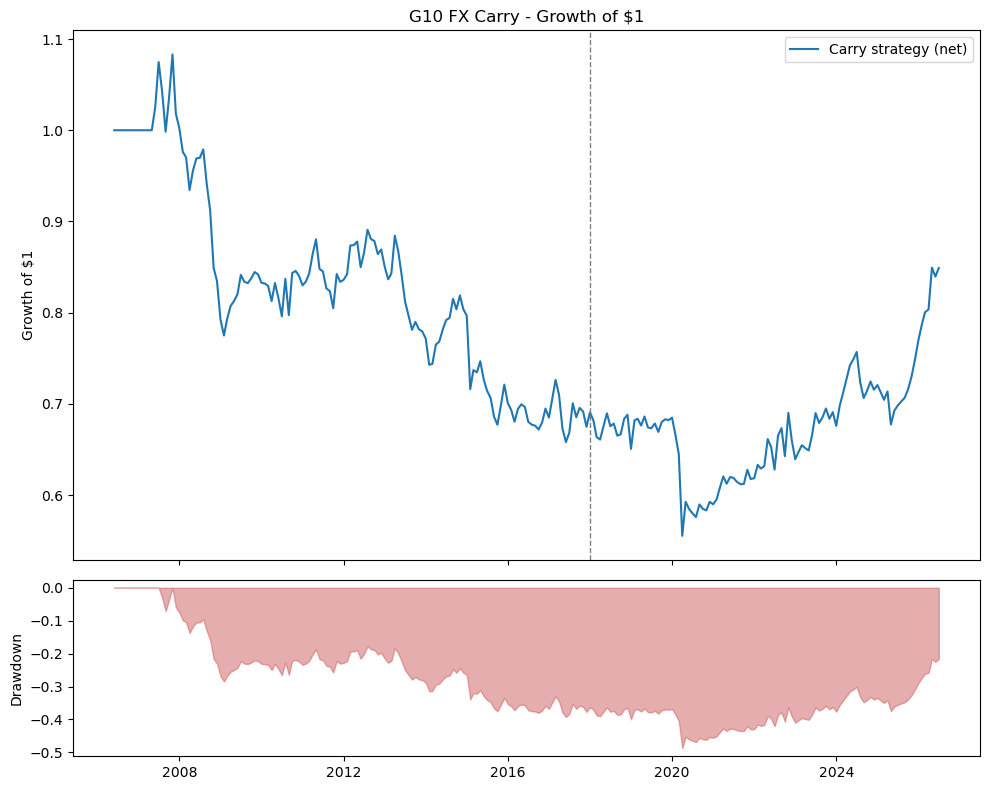

In [6]:
equity = (1+net).cumprod()
fig, ax = plt.subplots(2,1,figsize=(10,8),sharex=True,gridspec_kw={"height_ratios":[3,1]})
ax[0].plot(equity.index, equity, label="Carry strategy (net)")
ax[0].axvline(pd.Timestamp(OOS_SPLIT), ls="--", c="grey", lw=1)
ax[0].set_title("G10 FX Carry - Growth of $1"); ax[0].set_ylabel("Growth of $1"); ax[0].legend()
dd = equity/equity.cummax()-1
ax[1].fill_between(dd.index, dd, 0, color="indianred", alpha=0.5); ax[1].set_ylabel("Drawdown")
fig.tight_layout(); fig.savefig("fx_carry_results.png", dpi=120); plt.show()

## Limitations
- Monthly rebalancing on monthly rate data; intraday execution not modelled.
- Flat transaction-cost assumption.
- If a FRED series stops updating, its rate is carried forward; swap the series ID for an equivalent 3-month rate if needed.